# Preprocessing / Filtering

In [31]:
!pip install opencv-python
!pip install tensorflow
!pip install matplotlib
!pip install scipy

   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.5 MB 9.6 MB/s eta 0:00:04
   -- ------------------------------------- 2.6/36.5 MB 7.6 MB/s eta 0:00:05
   ---- ----------------------------------- 3.7/36.5 MB 6.4 MB/s eta 0:00:06
   ----- ---------------------------------- 5.2/36.5 MB 6.6 MB/s eta 0:00:05
   ------ --------------------------------- 6.3/36.5 MB 6.4 MB/s eta 0:00:05
   -------- ------------------------------- 7.6/36.5 MB 6.2 MB/s eta 0:00:05
   --------- ------------------------------ 8.7/36.5 MB 6.0 MB/s eta 0:00:05
   ---------- ----------------------------- 9.7/36.5 MB 6.0 MB/s eta 0:00:05
   ------------ --------------------------- 11.0/36.5 MB 5.9 MB/s eta 0:00:05
   ------------- -------------------------- 12.3/36.5 MB 5.9 MB/s eta 0:00:05
   -------------- ------------------------- 13.4/36.5 MB 5.9 MB/s eta 0:00:04
   ---------------- ----------------------- 14.7/36.5 MB 5.9 MB/s eta 0:00:04
  

In [ ]:
# Import Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [40]:
# Resize Images
IMG_SIZE = 224

def preprocess_image(img_path):

    # Load image
    img = cv2.imread(img_path)

    # BGR -> RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Gaussian Blur
    img = cv2.GaussianBlur(img, (5,5), 0)

    # CLAHE
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    gray = clahe.apply(gray)

    # Convert back to RGB
    img = cv2.cvtColor(
        gray,
        cv2.COLOR_GRAY2RGB
    )

    return img

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9904\3271112633.py:2: SyntaxWarning: invalid escape sequence '\C'
  sample_path = "C:\CodeC++\Digital Image project\Brain-Tumor-Classification-\Dataset\Testing\glioma\Te-gl_1.jpg"


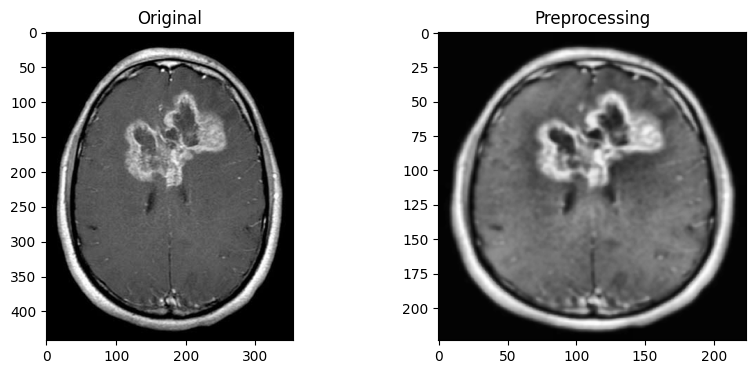

In [ ]:
# Example preprocessing on a sample image
sample_path = "" #Your img path here

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

preprocess_img = preprocess_image(sample_path)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(preprocess_img, cmap='gray')
plt.title("Preprocessing")

plt.show()

# Data Augmentation

In [43]:
# Train data
datagen = ImageDataGenerator(

    rotation_range=15,

    width_shift_range=0.1,
    height_shift_range=0.1,

    zoom_range=0.1,

    shear_range=0.1,

    horizontal_flip=True,

    brightness_range=[0.8, 1.2],

    fill_mode='nearest'
)

# Save Preprocess and Augmented image in new file

In [ ]:
# Save Training_Preprocess file 
input_dir = "" #Your dir path here

output_dir = "..\Dataset\Training_Preprocess"

classes = [
    "glioma",
    "meningioma",
    "pituitary",
    "notumor"
]

for class_name in classes:

    os.makedirs(
        os.path.join(output_dir, class_name),
        exist_ok=True
    )

for class_name in classes:

    class_input_path = os.path.join(
        input_dir,
        class_name
    )

    class_output_path = os.path.join(
        output_dir,
        class_name
    )

    for file_name in os.listdir(class_input_path):

        img_path = os.path.join(
            class_input_path,
            file_name
        )

        try:
            img = preprocess_image(img_path)

            preprocessed_name = (
                f"{os.path.splitext(file_name)[0]}_preprocessed.jpg"
            )

            preprocessed_path = os.path.join(
                class_output_path,
                preprocessed_name
            )

            save_img = cv2.cvtColor(
                img,
                cv2.COLOR_RGB2BGR
            )

            cv2.imwrite(
                preprocessed_path,
                save_img
            )

            img_array = np.expand_dims(
                img.astype(np.float32),
                axis=0
            )

            aug_iter = datagen.flow(
                img_array,
                batch_size=1
            )

            for i in range(5):

                batch = next(aug_iter)

                aug_img = batch[0]

                aug_img = np.clip(
                    aug_img,
                    0,
                    255
                ).astype(np.uint8)

                aug_name = (
                    f"{os.path.splitext(file_name)[0]}_aug_{i}.jpg"
                )

                aug_path = os.path.join(
                    class_output_path,
                    aug_name
                )

                aug_img = cv2.cvtColor(
                    aug_img,
                    cv2.COLOR_RGB2BGR
                )

                cv2.imwrite(
                    aug_path,
                    aug_img
                )

        except Exception as e:

            print(f"Error processing {img_path}")
            print(e)

print("DONE")

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:4: SyntaxWarning: invalid escape sequence '\D'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9904\3229985805.py:2: SyntaxWarning: invalid escape sequence '\C'
  input_dir = "C:\CodeC++\Digital Image project\Brain-Tumor-Classification-\Dataset\Training"
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9904\3229985805.py:4: SyntaxWarning: invalid escape sequence '\D'
  output_dir = "..\Dataset\Training_Preprocess"


DONE


In [ ]:
# Save Testing_Preprocess file NO AUGMENTATION
input_dir = "" #Your dir path here

output_dir = "..\Dataset\Testing_Preprocess"

classes = [
    "glioma",
    "meningioma",
    "pituitary",
    "notumor"
]

for class_name in classes:

    os.makedirs(
        os.path.join(output_dir, class_name),
        exist_ok=True
    )

for class_name in classes:

    class_input_path = os.path.join(
        input_dir,
        class_name
    )

    class_output_path = os.path.join(
        output_dir,
        class_name
    )

    for file_name in os.listdir(class_input_path):

        img_path = os.path.join(
            class_input_path,
            file_name
        )

        try:
            img = preprocess_image(img_path)

            preprocessed_name = (
                f"{os.path.splitext(file_name)[0]}_preprocessed.jpg"
            )

            preprocessed_path = os.path.join(
                class_output_path,
                preprocessed_name
            )

            save_img = cv2.cvtColor(
                img,
                cv2.COLOR_RGB2BGR
            )

            cv2.imwrite(
                preprocessed_path,
                save_img
            )

        except Exception as e:

            print(f"Error processing {img_path}")
            print(e)

print("DONE")

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:4: SyntaxWarning: invalid escape sequence '\D'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9904\397598378.py:2: SyntaxWarning: invalid escape sequence '\C'
  input_dir = "C:\CodeC++\Digital Image project\Brain-Tumor-Classification-\Dataset\Testing" #Your dir path here
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9904\397598378.py:4: SyntaxWarning: invalid escape sequence '\D'
  output_dir = "..\Dataset\Testing_Preprocess"


DONE
